<a href="https://colab.research.google.com/github/ithelga/beeline-banner-ab-test/blob/dev/notebooks/Team1_HW5_CDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SmartAds Efficiency**: Оптимизация эффективности маркетинговых каналов

## [STAGE 4] **Проведение подтверждающего анализ (СDA)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
import polars as pl
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, proportion_effectsize
from statsmodels.stats.contingency_tables import Table2x2
from scipy.stats import fisher_exact
from statsmodels.stats.power import NormalIndPower

warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

colors = ["#FFAFCC", "#FFC8DD", "#CDB4DB", "#BDE0FE", "#A2D2FF"] # СТАРЫЕ ЦВЕТА!!!!!!!!!!!!!!!!!!!!!!

graph_path = 'drive/MyDrive/Colab Notebooks/Beeline Banner AB-test/graph'
data_path = 'drive/MyDrive/Colab Notebooks/Beeline Banner AB-test/data'

Mounted at /content/drive


### Загружаем данные с Google Disk

In [ ]:
supertable = pd.read_csv(f'{data_path}/supertable.csv')
supertable.head()

,user_id,timestamp,date,shows,clicks,banner_first,campaign_first,placement,device_type,os,geo,has_install_event,has_first_order_event,has_registration_event,has_tariff_switch_event,segment,tariff,creative_type,size,target_audience_segment
0,1,2025-02-10 10:06:23,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
1,1,2025-02-15 20:05:59,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
2,1,2025-02-16 08:34:35,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
3,1,2025-02-17 21:55:14,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression
4,1,2025-03-01 20:13:19,NaN,0,0,NaN,no_impression,NaN,NaN,NaN,NaN,0,0,0,0,premium,premium,no_impression,no_impression,no_impression


### Агрегируем данные

In [ ]:
# ПАРАМЕТРЫ ДЛЯ ТЕСТОВ ПО ДАННЫМ SUPERTABLE

# ---------- Гипотеза 1 ----------
static_shows  = supertable.loc[supertable.creative_type == "static", "shows"].sum()
static_clicks = supertable.loc[supertable.creative_type == "static", "clicks"].sum()

animated_shows  = supertable.loc[supertable.creative_type.isin(["video", "rich"]), "shows"].sum()
animated_clicks = supertable.loc[supertable.creative_type.isin(["video", "rich"]), "clicks"].sum()


# ---------- Гипотеза 2 ----------
web_shows     = supertable.loc[supertable.os == "web", "shows"].sum()
web_clicks    = supertable.loc[supertable.os == "web", "clicks"].sum()

mobile_shows  = supertable.loc[supertable.os.isin(["android", "ios"]), "shows"].sum()
mobile_clicks = supertable.loc[supertable.os.isin(["android", "ios"]), "clicks"].sum()


# ---------- Гипотеза 3 ----------
app_shows     = supertable.loc[supertable.placement == "app", "shows"].sum()
app_switches  = supertable.loc[supertable.placement == "app", "has_tariff_switch_event"].sum()

site_shows    = supertable.loc[supertable.placement == "site", "shows"].sum()
site_switches = supertable.loc[supertable.placement == "site", "has_tariff_switch_event"].sum()

social_shows    = supertable.loc[supertable.placement == "social", "shows"].sum()
social_switches = supertable.loc[supertable.placement == "social", "has_tariff_switch_event"].sum()


# ---------- Гипотеза 4 ----------
tablet_regs  = supertable.loc[supertable.device_type == "tablet", "has_registration_event"].sum()
tablet_sw    = supertable.loc[supertable.device_type == "tablet", "has_tariff_switch_event"].sum()

phone_regs   = supertable.loc[supertable.device_type == "phone", "has_registration_event"].sum()
phone_sw     = supertable.loc[supertable.device_type == "phone", "has_tariff_switch_event"].sum()

### Выбираем подходящий тест

In [ ]:
class TestSelector:
    """
    Автоматический выбор статистического теста по правилам.

    Логика:
    - Fisher, если:
        * total < 50,
        * successes < 5,
        * failures < 5,
        * ИЛИ спец. случай для очень малых CTR: total < 150 и p < 0.15
    - Bonferroni при comparisons > 1
    - Иначе Z-test
    """

    def __init__(self, alpha=0.1):
        self.alpha = alpha

    def _need_fisher(self, succ, total):
        failures = total - succ
        p = succ / total if total > 0 else 0

        if total < 50 or succ < 5 or failures < 5:
            return True

        if total < 150 and p < 0.15:
            return True

        return False

    def choose_test(self, succ_a, total_a, succ_b, total_b, comparisons=1):
        if self._need_fisher(succ_a, total_a) or self._need_fisher(succ_b, total_b):
            return {
                "test": "fisher",
                "reason": (
                    "Выбран Fisher: одна из групп мала (total < 50 / successes < 5 / "
                    "failures < 5) или total < 150 при низкой конверсии (<15%)."
                )
            }

        if comparisons > 1:
            return {
                "test": "z-test + bonferroni",
                "reason": "Выбран Z-test + Bonferroni, так как comparisons > 1."
            }

        return {
            "test": "z-test",
            "reason": "Выбран Z-test — выборки достаточно большие."
        }

In [ ]:
# ---------- Гипотеза 1 ----------

selector = TestSelector()

selector.choose_test(
    succ_a=animated_clicks,
    total_a=animated_shows,
    succ_b=static_clicks,
    total_b=static_shows
)


{'test': 'z-test', 'reason': 'Выбран Z-test — выборки достаточно большие.'}

In [ ]:
# ---------- Гипотеза 2 ----------

selector.choose_test(
    succ_a=web_clicks,
    total_a=web_shows,
    succ_b=mobile_clicks,
    total_b=mobile_shows
)


{'test': 'fisher',
 'reason': 'Выбран Fisher: одна из групп мала (total < 50 / successes < 5 / failures < 5) или total < 150 при низкой конверсии (<15%).'}

In [ ]:
# ---------- Гипотеза 3 ----------
selector.choose_test(app_switches, app_shows, site_switches, site_shows, comparisons=2)
selector.choose_test(app_switches, app_shows, social_switches, social_shows, comparisons=2)

{'test': 'z-test + bonferroni',
 'reason': 'Выбран Z-test + Bonferroni, так как comparisons > 1.'}

In [ ]:
# ---------- Гипотеза 4 ----------
selector.choose_test(tablet_sw, tablet_regs, phone_sw, phone_regs)

{'test': 'z-test', 'reason': 'Выбран Z-test — выборки достаточно большие.'}

### Проверяем гипотезы

In [ ]:
class ZTest:
    """Z-test для сравнения двух пропорций pA > pB."""

    def run(self, succ_a, total_a, succ_b, total_b, alpha=0.1):
        p_a = succ_a / total_a
        p_b = succ_b / total_b
        lift = p_a / p_b - 1

        # z-test
        stat, p_value = proportions_ztest(
            [succ_a, succ_b],
            [total_a, total_b],
            alternative="larger"
        )

        # CI для разницы
        se = np.sqrt(
            p_a * (1 - p_a) / total_a +
            p_b * (1 - p_b) / total_b
        )
        diff = p_a - p_b
        z = 1.645  # Для alpha=0.1 (90% CI)
        diff_low, diff_high = diff - z * se, diff + z * se
        ci_lift = (diff_low / p_b, diff_high / p_b)

        return {
            "method": "z-test",
            "p_value": p_value,
            "p_a": p_a,
            "p_b": p_b,
            "lift": lift,
            "ci_lift": ci_lift
        }

In [ ]:
class FisherTest:
    """Fisher's Exact Test с CI для отношения шансов."""

    def run(self, succ_a, total_a, succ_b, total_b, alpha=0.1):
        table = [
            [succ_a, total_a - succ_a],
            [succ_b, total_b - succ_b]
        ]

        # Односторонний тест
        odds_ratio, p_value = fisher_exact(table, alternative="greater")

        p_a = succ_a / total_a
        p_b = succ_b / total_b
        lift = p_a / p_b - 1

        # CI для отношения шансов через statsmodels
        try:
            table_obj = Table2x2(table)
            # alpha*2 потому что CI двусторонний
            ci_or = table_obj.oddsratio_confint(alpha=alpha*2)

            # Конвертируем OR в lift (приближенно)
            # OR = odds_a / odds_b ≈ (p_a/(1-p_a)) / (p_b/(1-p_b))
            # Для малых p: OR ≈ p_a/p_b = 1 + lift
            if ci_or[0] is not None and ci_or[1] is not None:
                ci_lift = (ci_or[0] - 1, ci_or[1] - 1)
            else:
                ci_lift = None
        except:
            # Fallback: приближенный CI
            if total_a > 0 and total_b > 0:
                se = np.sqrt(
                    p_a * (1 - p_a) / total_a +
                    p_b * (1 - p_b) / total_b
                )
                diff = p_a - p_b
                z = 1.645
                diff_low, diff_high = diff - z * se, diff + z * se
                ci_lift = (diff_low / p_b, diff_high / p_b) if p_b > 0 else None
            else:
                ci_lift = None

        return {
            "method": "fisher",
            "p_value": p_value,
            "p_a": p_a,
            "p_b": p_b,
            "lift": lift,
            "ci_lift": ci_lift
        }

In [ ]:
class BonferroniCorrector:
    """Коррекция p-value для нескольких сравнений."""

    @staticmethod
    def correct(p_value, comparisons):
        return min(p_value * comparisons, 1.0)

In [ ]:
class HypothesisEvaluator:
    """
    Двухуровневая проверка гипотезы:
    1) Проверка статистической значимости (p-value < alpha)
    2) Проверка бизнес-порога (нижняя граница CI лифта >= threshold)
    """

    def __init__(self, alpha=0.1):
        self.alpha = alpha

    def evaluate(self, test_class, succ_a, total_a, succ_b, total_b,
                 threshold=None, comparisons=1, name_a="Группа A", name_b="Группа B"):

        # Выполняем статистический тест
        results = test_class.run(succ_a, total_a, succ_b, total_b, alpha=self.alpha)

        method = results["method"]
        p_value = results["p_value"]

        # Коррекция Bonferroni для множественных сравнений
        if comparisons > 1:
            p_value_corrected = BonferroniCorrector.correct(p_value, comparisons)
        else:
            p_value_corrected = p_value

        # Уровень A — статистическая значимость
        effect_exists = p_value_corrected < self.alpha

        # Уровень B — бизнес-порог
        if threshold is not None and results["ci_lift"] is not None:
            ci_low, ci_high = results["ci_lift"]
            meets_threshold = ci_low >= threshold
        else:
            meets_threshold = None
            ci_low = ci_high = None

        # Формируем отчет
        summary = []
        summary.append(f"Проверка гипотезы: сравнение {name_a} и {name_b}")
        summary.append(f"Метод тестирования: {method}\n")

        # Фактические показатели
        summary.append("Фактические показатели:")
        summary.append(f"- Конверсия {name_a}: {results['p_a']*100:.2f}%")
        summary.append(f"- Конверсия {name_b}: {results['p_b']*100:.2f}%")
        summary.append(f"- Относительная разница (lift): {results['lift']*100:.2f}%\n")

        # Проверка статистической значимости
        summary.append("Проверка статистической значимости:")
        summary.append(f"- p-value = {p_value_corrected:.5f} (alpha = {self.alpha})")
        if effect_exists:
            summary.append("- Различие статистически значимо.\n")
        else:
            summary.append("- Статистически значимого различия не выявлено.\n")

        # Доверительный интервал для лифта
        if results["ci_lift"] is not None:
            low, high = results["ci_lift"]
            summary.append("Доверительный интервал относительного эффекта (90%):")
            summary.append(f"- от {low*100:.2f}% до {high*100:.2f}%\n")

        # Проверка бизнес-порога
        if threshold is not None and results["ci_lift"] is not None:
            threshold_pct = threshold * 100
            summary.append(f"Проверка бизнес-порога ({threshold_pct:.0f}%):")
            summary.append(f"- Нижняя граница CI: {low*100:.2f}%")
            if meets_threshold:
                summary.append("- Эффект достигает заданного порога.\n")
            else:
                summary.append("- Эффект не достигает заданного порога.\n")

        # Итоговое решение - 4 исхода

        if effect_exists and meets_threshold:
            summary.append("Итоговое решение: гипотеза подтверждается.")
            summary.append(f"Статистически значимый эффект и превышение бизнес-порога ({threshold_pct:.0f}%).")

        elif effect_exists and not meets_threshold:
            summary.append("Итоговое решение: гипотеза частично подтверждена.")
            summary.append(f"Есть статистически значимый эффект (p = {p_value_corrected:.4f}),")
            summary.append(f"но бизнес-порог {threshold_pct:.0f}% не достигнут (нижняя граница CI: {low*100:.2f}%).")

        elif not effect_exists and meets_threshold:
            summary.append("Итоговое решение: результат неоднозначный.")
            summary.append("Нижняя граница доверительного интервала превышает бизнес-порог,")
            summary.append(f"но статистическая значимость отсутствует (p = {p_value_corrected:.4f}).")
            summary.append("Рекомендация: собрать больше данных для повышения мощности анализа.")

        else:
            summary.append("Итоговое решение: гипотеза не подтверждается.")
            if not effect_exists and meets_threshold is False:
                summary.append(f"Нет статистической значимости (p = {p_value_corrected:.4f}), "
                              f"и нижняя граница доверительного интервала ({low*100:.2f}%) "
                              f"ниже порога {threshold_pct:.0f}%.")
            elif not effect_exists:
                summary.append(f"Нет статистической значимости (p = {p_value_corrected:.4f}).")
            elif meets_threshold is False:
                summary.append(f"Нижняя граница доверительного интервала ({low*100:.2f}%) "
                              f"ниже порога {threshold_pct:.0f}%.")


        summary_text = "\n".join(summary)

        return {
            **results,
            "p_value_corrected": p_value_corrected,
            "effect_exists": effect_exists,
            "meets_threshold": meets_threshold,
            "summary": summary_text
        }

#### Проверяем гипотезу 1

> Показ анимированного баннера дает CTR более чем на 25% выше по сравнению со статичным баннером.

In [ ]:
test = ZTest()
evaluator = HypothesisEvaluator()

result = evaluator.evaluate(
    test_class=test,
    succ_a=animated_clicks,
    total_a=animated_shows,
    succ_b=static_clicks,
    total_b=static_shows,
    threshold=0.25,
    name_a="Анимированные",
    name_b="Статичные"
)

print(result["summary"])

Проверка гипотезы: сравнение Анимированные и Статичные
Метод тестирования: z-test

Фактические показатели:
- Конверсия Анимированные: 9.63%
- Конверсия Статичные: 7.80%
- Относительная разница (lift): 23.43%

Проверка статистической значимости:
- p-value = 0.08350 (alpha = 0.1)
- Различие статистически значимо.

Доверительный интервал относительного эффекта (90%):
- от -4.64% до 51.51%

Проверка бизнес-порога (25%):
- Нижняя граница CI: -4.64%
- Эффект не достигает заданного порога.

Итоговое решение: гипотеза частично подтверждена.
Есть статистически значимый эффект (p = 0.0835),
но бизнес-порог 25% не достигнут (нижняя граница CI: -4.64%).


#### Проверяем гипотезу 2

> Пользователи веб-версии не менее, чем на 30% чаще кликают на рекламу (CTR), чем пользователи мобильного приложения

In [ ]:
# создаём нужный тест
test = FisherTest()

# проверяем гипотезу
evaluator = HypothesisEvaluator()

result_h2 = evaluator.evaluate(
    test,
    succ_a=web_clicks, total_a=web_shows,
    succ_b=mobile_clicks, total_b=mobile_shows,
    threshold=0.30,
    name_a="WEB",
    name_b="MOBILE"
)

print(result_h2["summary"])

Проверка гипотезы: сравнение WEB и MOBILE
Метод тестирования: fisher

Фактические показатели:
- Конверсия WEB: 11.36%
- Конверсия MOBILE: 8.44%
- Относительная разница (lift): 34.68%

Проверка статистической значимости:
- p-value = 0.16019 (alpha = 0.1)
- Статистически значимого различия не выявлено.

Доверительный интервал относительного эффекта (90%):
- от -3.80% до 101.22%

Проверка бизнес-порога (30%):
- Нижняя граница CI: -3.80%
- Эффект не достигает заданного порога.

Итоговое решение: гипотеза не подтверждается.
Нет статистической значимости (p = 0.1602).


#### Проверяем гипотезу 3

> Размещение рекламы в приложении увеличивает вероятность смены тарифа не менее чем на 25% по сравнению с сайтом/соц сетями

**APP > SITE**

In [ ]:
test_site = ZTest()

evaluator = HypothesisEvaluator()

result_h3_site = evaluator.evaluate(
    test_site,
    succ_a=app_switches, total_a=app_shows,
    succ_b=site_switches, total_b=site_shows,
    threshold=0.25,
    comparisons=2,
    name_a="APP",
    name_b="SITE"
)

print(result_h3_site["summary"])

Проверка гипотезы: сравнение APP и SITE
Метод тестирования: z-test

Фактические показатели:
- Конверсия APP: 14.14%
- Конверсия SITE: 10.89%
- Относительная разница (lift): 29.86%

Проверка статистической значимости:
- p-value = 0.06342 (alpha = 0.1)
- Различие статистически значимо.

Доверительный интервал относительного эффекта (90%):
- от 3.30% до 56.43%

Проверка бизнес-порога (25%):
- Нижняя граница CI: 3.30%
- Эффект не достигает заданного порога.

Итоговое решение: гипотеза частично подтверждена.
Есть статистически значимый эффект (p = 0.0634),
но бизнес-порог 25% не достигнут (нижняя граница CI: 3.30%).


**APP > SOCIAL**

In [ ]:
test_social = ZTest()

result_h3_social = evaluator.evaluate(
    test_social,
    succ_a=app_switches, total_a=app_shows,
    succ_b=social_switches, total_b=social_shows,
    threshold=0.25,
    comparisons=2,
    name_a="APP",
    name_b="SOCIAL"
)

print(result_h3_social["summary"])

Проверка гипотезы: сравнение APP и SOCIAL
Метод тестирования: z-test

Фактические показатели:
- Конверсия APP: 14.14%
- Конверсия SOCIAL: 11.22%
- Относительная разница (lift): 25.96%

Проверка статистической значимости:
- p-value = 0.17296 (alpha = 0.1)
- Статистически значимого различия не выявлено.

Доверительный интервал относительного эффекта (90%):
- от -4.53% до 56.46%

Проверка бизнес-порога (25%):
- Нижняя граница CI: -4.53%
- Эффект не достигает заданного порога.

Итоговое решение: гипотеза не подтверждается.
Нет статистической значимости (p = 0.1730).


Гипотеза не подтверждается, нет статистической значимости по APP и SOCIAL, и эффект в парах APP & SOCIAL и APP & SITE ниже порога.

#### Проверяем гипотезу 4

> Просмотр рекламы на устройстве tablet увеличивает вероятность смены тарифа более, чем на 10 %  по сравнению с другими устройствами после регистрации пользователей

In [ ]:
test = ZTest()

evaluator = HypothesisEvaluator()

result_h4 = evaluator.evaluate(
    test,
    succ_a=tablet_sw, total_a=tablet_regs,
    succ_b=phone_sw,  total_b=phone_regs,
    threshold=0.10,
    name_a="TABLET",
    name_b="PHONE"
)

print(result_h4["summary"])

Проверка гипотезы: сравнение TABLET и PHONE
Метод тестирования: z-test

Фактические показатели:
- Конверсия TABLET: 30.08%
- Конверсия PHONE: 26.94%
- Относительная разница (lift): 11.66%

Проверка статистической значимости:
- p-value = 0.23610 (alpha = 0.1)
- Статистически значимого различия не выявлено.

Доверительный интервал относительного эффекта (90%):
- от -15.63% до 38.96%

Проверка бизнес-порога (10%):
- Нижняя граница CI: -15.63%
- Эффект не достигает заданного порога.

Итоговое решение: гипотеза не подтверждается.
Нет статистической значимости (p = 0.2361).


### Анализируем мощность

In [ ]:
class PowerAnalyzer:
    """
    Анализ мощности тестов (power analysis) для сравнения двух конверсий.
    """

    def __init__(self, alpha=0.1, power_target=0.8):
        self.alpha = alpha
        self.power_target = power_target
        self.power_calc = NormalIndPower()

    def compute_power(self, p1, p2, n1, n2):
        effect = proportion_effectsize(p1, p2)
        return self.power_calc.power(effect, nobs1=n1, ratio=n2/n1, alpha=self.alpha)

    def required_sample(self, p1, p2):
        effect = proportion_effectsize(p1, p2)
        return self.power_calc.solve_power(effect, power=self.power_target, alpha=self.alpha)

    def bootstrap_lift(self, succ_a, total_a, succ_b, total_b, n_boot=5000):
        p_a = succ_a / total_a
        p_b = succ_b / total_b

        lifts = []
        for _ in range(n_boot):
            clicks_a = np.random.binomial(total_a, p_a)
            clicks_b = np.random.binomial(total_b, p_b)

            ctr_a = clicks_a / total_a
            ctr_b = clicks_b / total_b
            lift = (ctr_a - ctr_b) / ctr_b

            lifts.append(lift)
        return np.array(lifts)

    def plot_pair(self, lifts, p1, p2, name_a, name_b, max_n=6000):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Bootstrap
        axes[0].hist(lifts, bins=40, edgecolor="black", alpha=0.7)
        axes[0].axvline(np.mean(lifts), color="red", label="Средний лифт")
        axes[0].set_title(f"Bootstrap лифта: {name_a} vs {name_b}")
        axes[0].set_xlabel("Лифт")
        axes[0].set_ylabel("Частота")
        axes[0].legend()

        # Power Curve
        ns = np.arange(100, max_n, 200)
        effect = proportion_effectsize(p1, p2)
        powers = [self.power_calc.power(effect, nobs1=n, ratio=1.0, alpha=self.alpha) for n in ns]

        axes[1].plot(ns, powers)
        axes[1].axhline(self.power_target, color="red", linestyle="--", label=f"{int(self.power_target*100)}% мощность")
        axes[1].set_title(f"Power Curve: {name_a} vs {name_b}")
        axes[1].set_xlabel("Размер выборки в группе")
        axes[1].set_ylabel("Мощность теста")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    def analyze(self, succ_a, total_a, succ_b, total_b, name_a="A", name_b="B"):

        p_a = succ_a / total_a
        p_b = succ_b / total_b

        # Мощность
        power = self.compute_power(p_b, p_a, total_b, total_a)

        # Требуемый размер выборки
        try:
            required_n = self.required_sample(p_a, p_b)
        except Exception:
            required_n = None

        # Bootstrap
        lifts = self.bootstrap_lift(succ_a, total_a, succ_b, total_b)

        # Визуализация
        self.plot_pair(lifts, p_a, p_b, name_a, name_b)

        # Вывод
        print("\n==============================")
        print(f" АНАЛИЗ МОЩНОСТИ: {name_a} vs {name_b}")
        print("==============================")

        print(f"Текущий размер выборки: {name_a} = {total_a}, {name_b} = {total_b}")

        if required_n:
            print(f"Необходимый размер выборки: {required_n:.0f} на группу")
        else:
            print("Необходимый размер выборки: невозможно оценить (слишком маленький эффект).")

        print(f"\nТекущая мощность теста: {power:.3f}")
        print(f"Целевая мощность: {self.power_target}")

        print("\nBootstrap лифт:")
        print(f"- средний: {np.mean(lifts)*100:.2f}%")
        print(f"- 95% CI: {np.percentile(lifts, 2.5)*100:.2f}%, {np.percentile(lifts, 97.5)*100:.2f}%")

        return {
            "power": power,
            "required_n": required_n,
            "mean_lift": np.mean(lifts),
            "ci_bootstrap": (
                np.percentile(lifts, 2.5),
                np.percentile(lifts, 97.5),
            )
        }

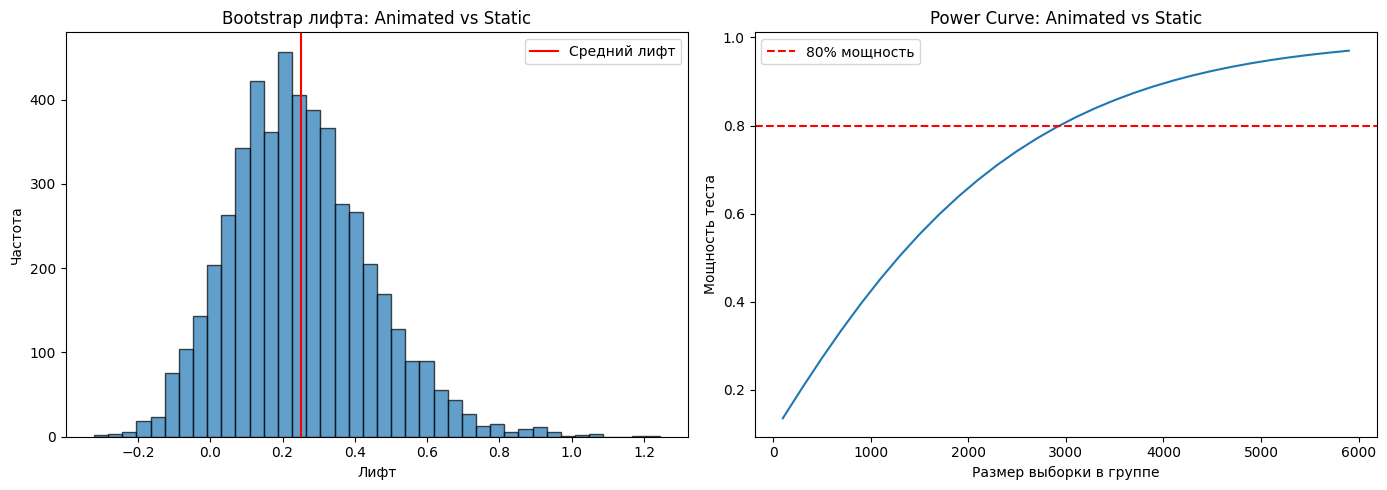


 АНАЛИЗ МОЩНОСТИ: Animated vs Static
Текущий размер выборки: Animated = 841, Static = 974
Необходимый размер выборки: 2935 на группу

Текущая мощность теста: 0.396
Целевая мощность: 0.8

Bootstrap лифт:
- средний: 25.01%
- 95% CI: -8.71%, 66.70%


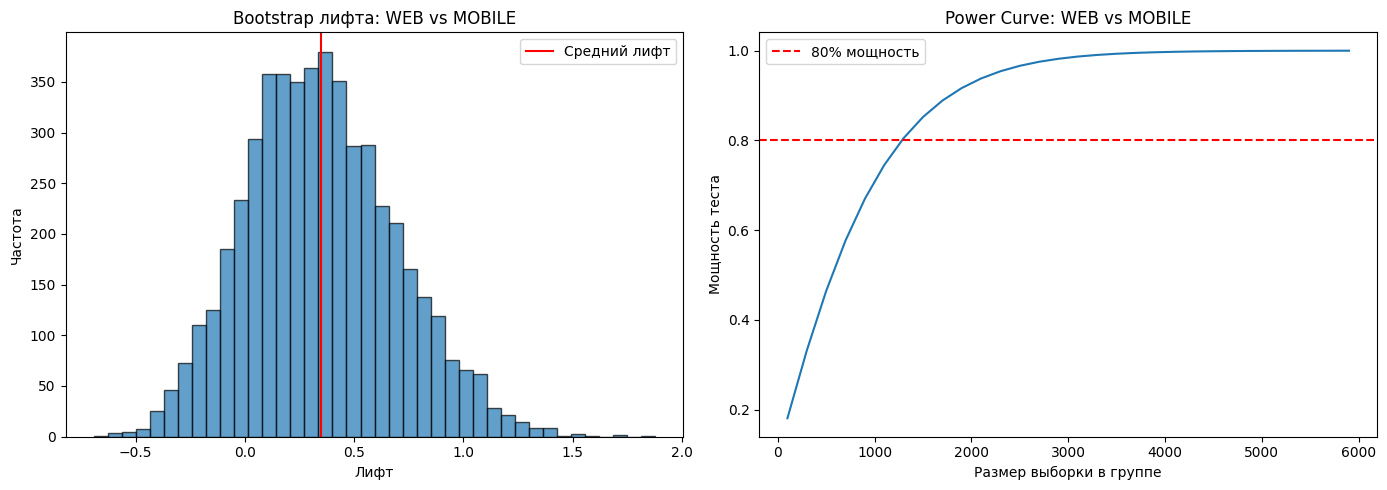


 АНАЛИЗ МОЩНОСТИ: WEB vs MOBILE
Текущий размер выборки: WEB = 132, MOBILE = 1683
Необходимый размер выборки: 1281 на группу

Текущая мощность теста: 0.292
Целевая мощность: 0.8

Bootstrap лифт:
- средний: 34.84%
- 95% CI: -27.14%, 107.19%


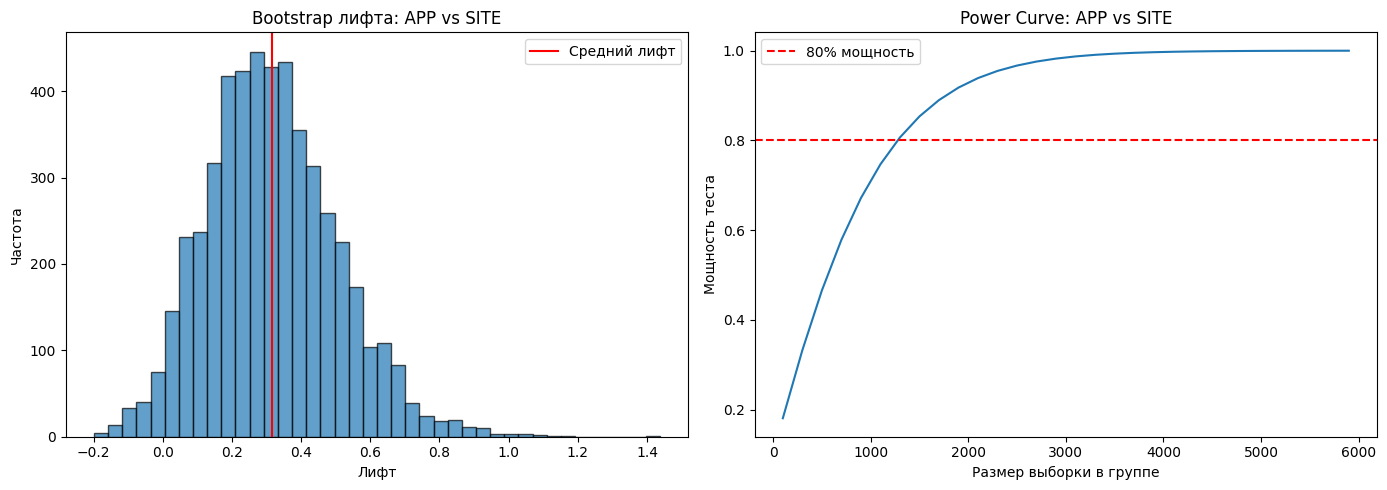


 АНАЛИЗ МОЩНОСТИ: APP vs SITE
Текущий размер выборки: APP = 679, SITE = 744
Необходимый размер выборки: 1275 на группу

Текущая мощность теста: 0.584
Целевая мощность: 0.8

Bootstrap лифт:
- средний: 31.61%
- 95% CI: -1.15%, 71.01%


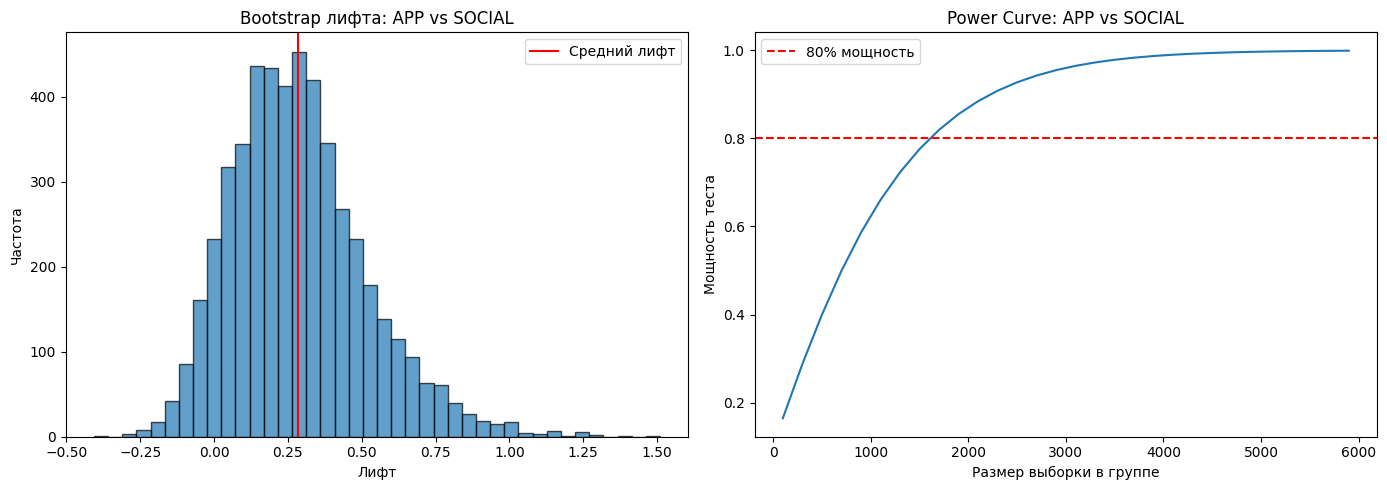


 АНАЛИЗ МОЩНОСТИ: APP vs SOCIAL
Текущий размер выборки: APP = 679, SOCIAL = 392
Необходимый размер выборки: 1608 на группу

Текущая мощность теста: 0.398
Целевая мощность: 0.8

Bootstrap лифт:
- средний: 28.59%
- 95% CI: -8.68%, 80.89%


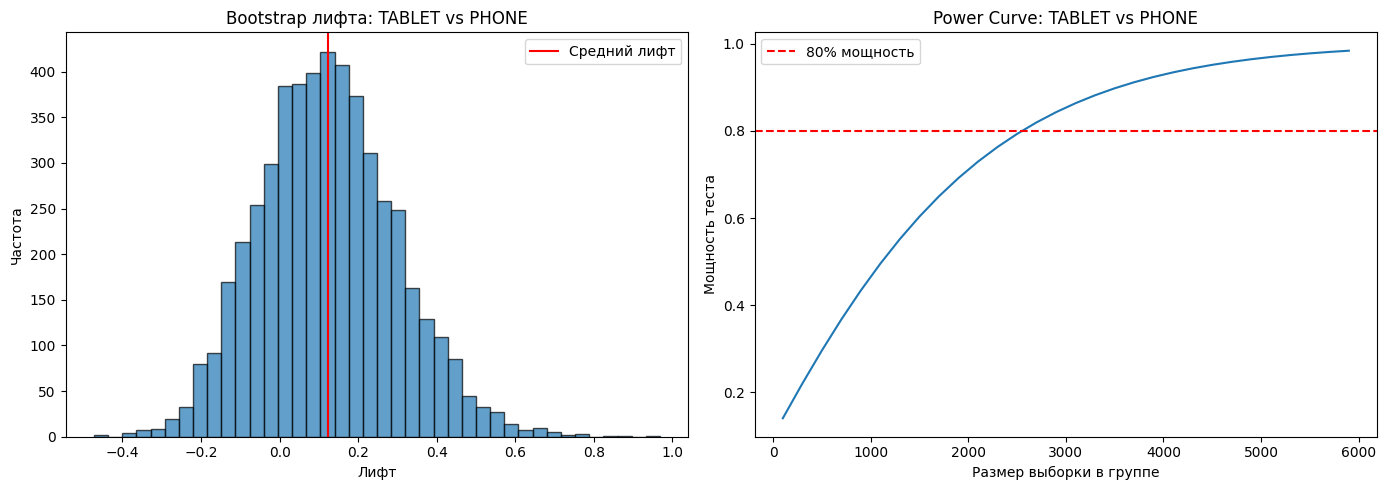


 АНАЛИЗ МОЩНОСТИ: TABLET vs PHONE
Текущий размер выборки: TABLET = 123, PHONE = 683
Необходимый размер выборки: 2552 на группу

Текущая мощность теста: 0.184
Целевая мощность: 0.8

Bootstrap лифт:
- средний: 12.24%
- 95% CI: -19.19%, 48.08%


In [ ]:
analyzer = PowerAnalyzer(alpha=0.1, power_target=0.8)


# Гипотеза 1 — Animated vs Static
result_h1 = analyzer.analyze(
    succ_a=animated_clicks,
    total_a=animated_shows,
    succ_b=static_clicks,
    total_b=static_shows,
    name_a="Animated",
    name_b="Static"
)

# Гипотеза 2 — WEB vs MOBILE
result_h2 = analyzer.analyze(
    succ_a=web_clicks,
    total_a=web_shows,
    succ_b=mobile_clicks,
    total_b=mobile_shows,
    name_a="WEB",
    name_b="MOBILE"
)

# Гипотеза 3 — APP vs SITE
result_h3_site = analyzer.analyze(
    succ_a=app_switches,
    total_a=app_shows,
    succ_b=site_switches,
    total_b=site_shows,
    name_a="APP",
    name_b="SITE"
)

# Гипотеза 3 — APP vs SOCIAL
result_h3_social = analyzer.analyze(
    succ_a=app_switches,
    total_a=app_shows,
    succ_b=social_switches,
    total_b=social_shows,
    name_a="APP",
    name_b="SOCIAL"
)

# Гипотеза 4 — Tablet vs Phone
result_h4 = analyzer.analyze(
    succ_a=tablet_sw,
    total_a=tablet_regs,
    succ_b=phone_sw,
    total_b=phone_regs,
    name_a="TABLET",
    name_b="PHONE"
)


**Итоговый вывод по анализу мощности**

Анализ мощности показал, что во всех четырёх гипотезах текущего **объёма данных недостаточно**, чтобы **статистически** подтвердить наблюдаемые эффекты.

Хотя фактические лифты выглядят положительными (от +12% до +36%), тесты обладают низкой мощностью:

* мощность колеблется от **0.18 до 0.58** при требуемом уровне 0.80;
* доверительные интервалы широкие и включают **отрицательные значения**;
* bootstrap-распределения эффектов нестабильны и **не позволяют** уверенно **отделить эффект от шума**.

Для достижения требуемой мощности 80% необходимы существенно большие выборки:
для разных гипотез — от 1,200 до 3,000 наблюдений на группу, что в **2–10 раз** превышает текущие размеры выборок.

**Вывод:**

1. Неподтверждение гипотез в CDA объясняется недостатком данных, а не отсутствием эффекта.
2. Эффекты могут быть реальными, но статистических оснований для выводов сейчас нет.

**Рекомендации:**

1. Увеличить объём данных перед повторной проверкой гипотез;
2. Уделить особое внимание группам с особо низкой выборкой (WEB, TABLET, SOCIAL);
3. При возможности — провести A/B-эксперимент для прямого измерения эффекта.